In [1]:
import datacube
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy


import sys
sys.path.insert(1, "../Tools/")
from dea_tools.plotting import display_map, xr_animation, rgb
from dea_tools.dask import create_local_dask_cluster

In [2]:
dc = datacube.Datacube(app="water difference 2023-2024 example TCP")

In [3]:
create_local_dask_cluster()

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/8787/status,
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/8787/status,Workers: 1
Total threads: 2,Total memory: 12.21 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:36259,Workers: 1
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/8787/status,Total threads: 2
Started: Just now,Total memory: 12.21 GiB
Comm: tcp://127.0.0.1:44343,Total threads: 2
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/40347/status,Memory: 12.21 GiB
Nanny: tcp://127.0.0.1:41889,


2025-04-07 06:40:33,009 - distributed.scheduler - WARNING - Detected different `run_spec` for key 'dataset-a3059652b59549ef99f1dfc74b0fc307' between two consecutive calls to `update_graph`. This can cause failures and deadlocks down the line. Please ensure unique key names. If you are using a standard dask collections, consider releasing all the data before resubmitting another computation. More details and help can be found at https://github.com/dask/dask/issues/9888. 
Debugging information
---------------------
old task state: released
old run_spec: (<function execute_task at 0x7f9ae968df30>, (Dataset <id=a3059652-b595-49ef-99f1-dfc74b0fc307 product=ga_ls_tc_pc_cyear_3 location=s3://dea-public-data/derivative/ga_ls_tc_pc_cyear_3/2-0-0/x45/y52/2023--P1Y/ga_ls_tc_pc_cyear_3_x45y52_2023--P1Y_final.stac-item.json>,), {})
new run_spec: (<function execute_task at 0x7f9ae968df30>, (Dataset <id=a3059652-b595-49ef-99f1-dfc74b0fc307 product=ga_ls_tc_pc_cyear_3 location=s3://dea-public-data/der

In [16]:
lat = -16.7697
lon = 131.2288

lat_buffer = 0.5
lon_buffer = 0.5


lat_range = (lat - lat_buffer, lat + lat_buffer)
lon_range = (lon - lon_buffer, lon + lon_buffer)


start_year = "2023"
end_year = "2024"

In [17]:
display_map(lon_range, lat_range)

In [18]:
query = {
    "x": lon_range,
    "y": lat_range,
    "resolution": (-90, 90),
    "time": (start_year, end_year),
    "dask_chunks": {}
}

products = ["ga_ls_tc_pc_cyear_3", "ga_ls_fc_pc_cyear_3"]

In [19]:
measurements = dc.list_measurements()
measurements.loc[products]

name  dtype    units nodata aliases  \
product             measurement                                                 
ga_ls_tc_pc_cyear_3 wet_pc_10        wet_pc_10  int16  percent  -9999     NaN   
                    wet_pc_50        wet_pc_50  int16  percent  -9999     NaN   
                    wet_pc_90        wet_pc_90  int16  percent  -9999     NaN   
                    green_pc_10    green_pc_10  int16  percent  -9999     NaN   
                    green_pc_50    green_pc_50  int16  percent  -9999     NaN   
                    green_pc_90    green_pc_90  int16  percent  -9999     NaN   
                    bright_pc_10  bright_pc_10  int16  percent  -9999     NaN   
                    bright_pc_50  bright_pc_50  int16  percent  -9999     NaN   
                    bright_pc_90  bright_pc_90  int16  percent  -9999     NaN   
ga_ls_fc_pc_cyear_3 pv_pc_10          pv_pc_10  uint8  percent    255     NaN   
                    pv_pc_50          pv_pc_50  uint8  percent    255     NaN   
                    pv_pc_90          pv_pc_90  uint8  percent    255     NaN   
                    bs_pc_10          bs_pc_10  uint8  percent    255     NaN   
                    bs_pc_50          bs_pc_50  uint8  percent    255     NaN   
                    bs_pc_90          bs_pc_90  uint8  percent    255     NaN   
                    npv_pc_10        npv_pc_10  uint8  percent    255     NaN   
                    npv_pc_50        npv_pc_50  uint8  percent    255     NaN   
                    npv_pc_90        npv_pc_90  uint8  percent    255     NaN   
                    qa                      qa  uint8        1    255     NaN   

                                                                   flags_definition  
product             measurement                                                      
ga_ls_tc_pc_cyear_3 wet_pc_10                                                   NaN  
                    wet_pc_50                                                   NaN  
                    wet_pc_90                                                   NaN  
                    green_pc_10                                                 NaN  
                    green_pc_50                                                 NaN  
                    green_pc_90                                                 NaN  
                    bright_pc_10                                                NaN  
                    bright_pc_50                                                NaN  
                    bright_pc_90                                                NaN  
ga_ls_fc_pc_cyear_3 pv_pc_10                                                    NaN  
                    pv_pc_50                                                    NaN  
                    pv_pc_90                                                    NaN  
                    bs_pc_10                                                    NaN  
                    bs_pc_50                                                    NaN  
                    bs_pc_90                                                    NaN  
                    npv_pc_10                                                   NaN  
                    npv_pc_50                                                   NaN  
                    npv_pc_90                                                   NaN  
                    qa            {'qa': {'bits': [0, 1, 2, 3, 4, 5, 6, 7], 'val...

In [20]:
ds = xr.merge([dc.load(
    product=product,
    **query
) for product in products])

In [21]:
ds

<xarray.Dataset> Size: 83MB
Dimensions:       (time: 2, y: 1233, x: 1196)
Coordinates:
  * time          (time) datetime64[ns] 16B 2023-07-02T11:59:59.999999 2024-0...
  * y             (y) float64 10kB -1.731e+06 -1.731e+06 ... -1.842e+06
  * x             (x) float64 10kB -1.365e+05 -1.364e+05 ... -2.894e+04
    spatial_ref   int32 4B 3577
Data variables: (12/19)
    wet_pc_10     (time, y, x) int16 6MB dask.array<chunksize=(1, 1233, 1196), meta=np.ndarray>
    wet_pc_50     (time, y, x) int16 6MB dask.array<chunksize=(1, 1233, 1196), meta=np.ndarray>
    wet_pc_90     (time, y, x) int16 6MB dask.array<chunksize=(1, 1233, 1196), meta=np.ndarray>
    green_pc_10   (time, y, x) int16 6MB dask.array<chunksize=(1, 1233, 1196), meta=np.ndarray>
    green_pc_50   (time, y, x) int16 6MB dask.array<chunksize=(1, 1233, 1196), meta=np.ndarray>
    green_pc_90   (time, y, x) int16 6MB dask.array<chunksize=(1, 1233, 1196), meta=np.ndarray>
    ...            ...
    bs_pc_50      (time, y, x) uint8 3MB dask.array<chunksize=(1, 1233, 1196), meta=np.ndarray>
    bs_pc_90      (time, y, x) uint8 3MB dask.array<chunksize=(1, 1233, 1196), meta=np.ndarray>
    npv_pc_10     (time, y, x) uint8 3MB dask.array<chunksize=(1, 1233, 1196), meta=np.ndarray>
    npv_pc_50     (time, y, x) uint8 3MB dask.array<chunksize=(1, 1233, 1196), meta=np.ndarray>
    npv_pc_90     (time, y, x) uint8 3MB dask.array<chunksize=(1, 1233, 1196), meta=np.ndarray>
    qa            (time, y, x) uint8 3MB dask.array<chunksize=(1, 1233, 1196), meta=np.ndarray>
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

In [22]:
ds['green_pc_90']

<xarray.DataArray 'green_pc_90' (time: 2, y: 1233, x: 1196)> Size: 6MB
dask.array<dc_load_green_pc_90, shape=(2, 1233, 1196), dtype=int16, chunksize=(1, 1233, 1196), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 16B 2023-07-02T11:59:59.999999 2024-07...
  * y            (y) float64 10kB -1.731e+06 -1.731e+06 ... -1.842e+06
  * x            (x) float64 10kB -1.365e+05 -1.364e+05 ... -2.894e+04
    spatial_ref  int32 4B 3577
Attributes:
    units:         percent
    nodata:        -9999
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

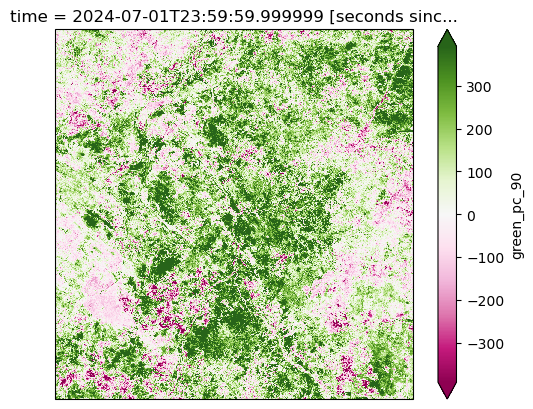

In [23]:
f, ax =plt.subplots(subplot_kw=dict(projection=cartopy.crs.epsg(3577)))
data = ds.diff('time').green_pc_90[0].astype(float)
data.plot(ax=ax, cmap='PiYG',
               vmin=-np.max([np.abs(data.min()), data.max()]) * 0.2,
               vmax=np.max([np.abs(data.min()), data.max()]) * 0.2)
# im = ax.imshow(data, cmap='PiYG',
#                vmin=-np.max([np.abs(data.min()), data.max()]) * 0.2,
#                vmax=np.max([np.abs(data.min()), data.max()]) * 0.2)

The above figure shows the difference between the 2023 and 2024 Tasselled capped greenness 90th percentile datasets. The 90th percentile represents the 'maximum' conditions for that calendar year (with 50 representing the middle and 10th percentile the minimum condition).

"The 10th, 50th and 90th percentiles of the Tasseled Cap are intended to capture the extreme (10th and 90th percentile) values and long-term average (50th percentile) values of each index"

"The Tasseled Cap Percentiles are intended to complement the DEA Water Observations (Water Observations from Space) and Fractional Cover algorithms"

"However if you are interested in terrestrial vegetation (where water in the pixel is not a factor), use the Fractional Cover product in preference to the Tasseled Cap, which provides a better biophysical characterisation of green vegetation fraction, dry vegetation fraction and bare soil vegetation fraction."


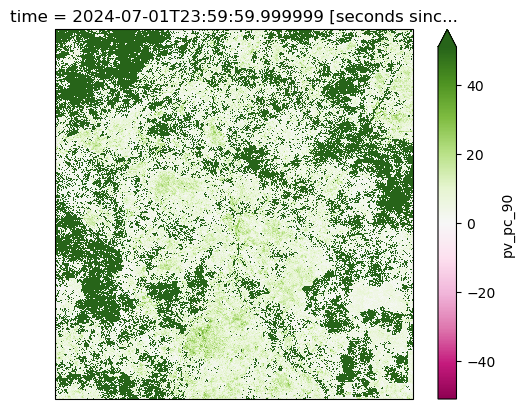

In [26]:
f, ax =plt.subplots(subplot_kw=dict(projection=cartopy.crs.epsg(3577)))
data = ds.diff('time').pv_pc_90[0].astype(float)
data.plot(ax=ax, cmap='PiYG',
               vmin=-np.max([np.abs(data.min()), data.max()]) * 0.2,
               vmax=np.max([np.abs(data.min()), data.max()]) * 0.2)